<a href="https://colab.research.google.com/github/meenakshimeenuzz21/DSA-Class-Notes/blob/main/DSA_G2_Examination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Understanding & Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/G2.csv")

In [ ]:
df.head()

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense
0,1,bulbasaur,7,69,64.0,grass,poison,45,49,49
1,2,ivysaur,10,130,142.0,grass,poison,60,62,63
2,3,venusaur,20,1000,236.0,grass,poison,80,82,83
3,4,charmander,6,85,62.0,fire,NaN,39,52,43
4,5,charmeleon,11,190,142.0,fire,NaN,58,64,58


In [ ]:
df.shape

(1351, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1351 non-null   int64  
 1   name             1351 non-null   object 
 2   height_dm        1351 non-null   int64  
 3   weight_hg        1351 non-null   int64  
 4   base_experience  1302 non-null   float64
 5   type_1           1351 non-null   object 
 6   type_2           765 non-null    object 
 7   hp               1351 non-null   int64  
 8   attack           1351 non-null   int64  
 9   defense          1351 non-null   int64  
dtypes: float64(1), int64(6), object(3)
memory usage: 105.7+ KB


In [ ]:
df.describe()

,id,height_dm,weight_hg,base_experience,hp,attack,defense
count,1351.000000,1351.000000,1351.000000,1302.000000,1351.000000,1351.000000,1351.000000
mean,2841.692080,20.443375,991.059956,161.943932,71.673575,82.757957,76.193930
std,4139.019112,53.238467,1953.115812,82.532554,26.827529,32.351906,30.712902
min,1.000000,1.000000,0.000000,36.000000,1.000000,5.000000,5.000000
25%,338.500000,6.000000,94.500000,71.000000,55.000000,60.000000,55.000000
50%,676.000000,11.000000,326.000000,165.000000,70.000000,80.000000,70.000000
75%,1013.500000,17.000000,853.500000,222.500000,85.000000,102.500000,95.000000
max,10326.000000,1000.000000,10000.000000,608.000000,255.000000,190.000000,250.000000


In [ ]:
df.select_dtypes(include="number").columns

Index(['id', 'height_dm', 'weight_hg', 'base_experience', 'hp', 'attack',
       'defense'],
      dtype='object')

In [ ]:
df.select_dtypes(include="object").columns

Index(['name', 'type_1', 'type_2'], dtype='object')

In [ ]:
df.isnull().sum()

,0
id,0
name,0
height_dm,0
weight_hg,0
base_experience,49
type_1,0
type_2,586
hp,0
attack,0
defense,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['id', 'name', 'height_dm', 'weight_hg', 'base_experience', 'type_1',
       'type_2', 'hp', 'attack', 'defense'],
      dtype='object')

In [ ]:
df.dtypes

,0
id,int64
name,object
height_dm,int64
weight_hg,int64
base_experience,float64
type_1,object
type_2,object
hp,int64
attack,int64
defense,int64


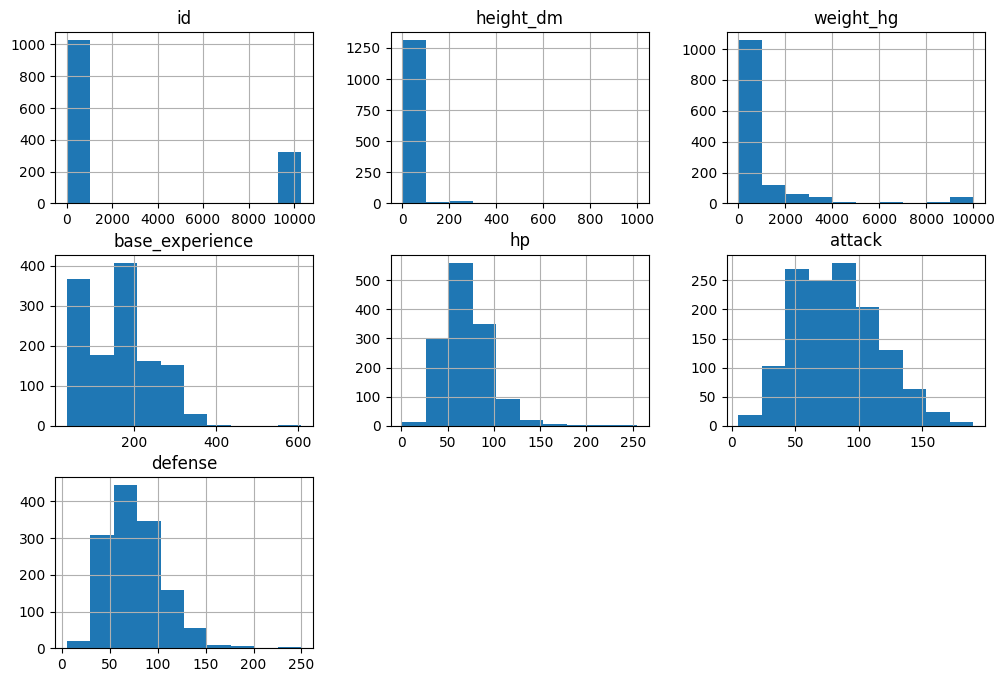

In [ ]:
df.hist(figsize=(12,8))
plt.show()

1. type_1 appears most frequently in the dataset

2. attack shows greatest variation

3. this dataset is used to predict the Pokemons primary battle type that include type_1 based on its physical attributes

Data Preprocessing

In [ ]:
df["base_experience"] = df["base_experience"].fillna(df["base_experience"]).mean()

df["type_1"] = df["type_1"].fillna(df["type_1"]).mode()[0]
df["type_2"] = df["type_2"].fillna(df["type_2"]).mode()[0]

In [ ]:
df.isnull().sum()

,0
id,0
name,0
height_dm,0
weight_hg,0
base_experience,0
type_1,0
type_2,0
hp,0
attack,0
defense,0


In [ ]:
for col in df.select_dtypes(include=[np.number]).columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR


    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Total Outliers in {col}: {len(outliers)}")

Total Outliers in id: 326
Total Outliers in height_dm: 95
Total Outliers in weight_hg: 174
Total Outliers in base_experience: 0
Total Outliers in hp: 30
Total Outliers in attack: 10
Total Outliers in defense: 19


In [ ]:
Q1 = df['weight_hg'].quantile(0.25)
Q3 = df['weight_hg'].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df = df[(df['weight_hg'] >= lower_bound) & (df['weight_hg'] <= upper_bound)]

print("Dataset Shape After Removing Outliers:", df.shape)

Dataset Shape After Removing Outliers: (1177, 10)


In [ ]:
Q1 = df['height_dm'].quantile(0.25)
Q3 = df['height_dm'].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df = df[(df['height_dm'] >= lower_bound) & (df['height_dm'] <= upper_bound)]

print("Dataset Shape After Removing Outliers:", df.shape)

Dataset Shape After Removing Outliers: (1161, 10)


In [ ]:
Q1 = df['id'].quantile(0.25)
Q3 = df['id'].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df = df[(df['id'] >= lower_bound) & (df['id'] <= upper_bound)]

print("Dataset Shape After Removing Outliers:", df.shape)

Dataset Shape After Removing Outliers: (924, 10)


In [ ]:
Q1 = df['attack'].quantile(0.25)
Q3 = df['attack'].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df = df[(df['attack'] >= lower_bound) & (df['attack'] <= upper_bound)]

print("Dataset Shape After Removing Outliers:", df.shape)

Dataset Shape After Removing Outliers: (921, 10)


In [ ]:
Q1 = df['defense'].quantile(0.25)
Q3 = df['defense'].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df = df[(df['defense'] >= lower_bound) & (df['defense'] <= upper_bound)]

print("Dataset Shape After Removing Outliers:", df.shape)

Dataset Shape After Removing Outliers: (905, 10)


In [ ]:
Q1 = df['hp'].quantile(0.25)
Q3 = df['hp'].quantile(0.75)
IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


df = df[(df['hp'] >= lower_bound) & (df['hp'] <= upper_bound)]

print("Dataset Shape After Removing Outliers:", df.shape)

Dataset Shape After Removing Outliers: (895, 10)


In [ ]:
df.head()

,id,name,height_dm,weight_hg,base_experience,type_1,type_2,hp,attack,defense
0,1,bulbasaur,7,69,161.943932,water,flying,45,49,49
1,2,ivysaur,10,130,161.943932,water,flying,60,62,63
2,3,venusaur,20,1000,161.943932,water,flying,80,82,83
3,4,charmander,6,85,161.943932,water,flying,39,52,43
4,5,charmeleon,11,190,161.943932,water,flying,58,64,58


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['type_1'] = le.fit_transform(df['type_1'])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(columns=['name', 'type_1'])

# Encode 'type_2' categorical column
le_type2 = LabelEncoder()
X['type_2'] = le_type2.fit_transform(X['type_2'])

y = df['type_1']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42 )

1. Preprocessing the model includes cleaning, analysing, finding duplicates and correcting it otherwise it will lead to data leakage and the model will not work as predicted

2. Using mode() fillna because it is a categorical column

Exploratory Data Analysis

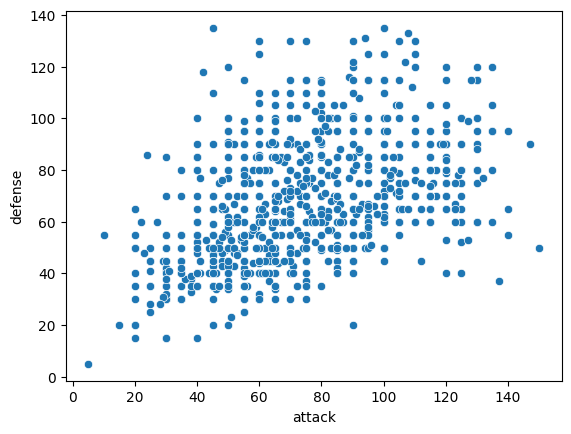

In [ ]:
sns.scatterplot(x="attack", y="defense", data=df)
plt.show()

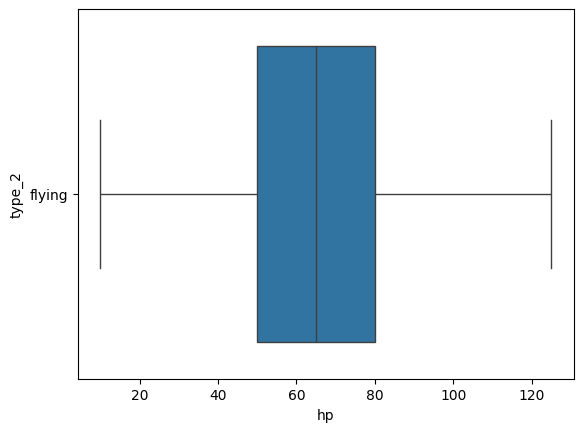

In [ ]:
sns.boxplot(x="hp", y="type_2", data=df)
plt.show()

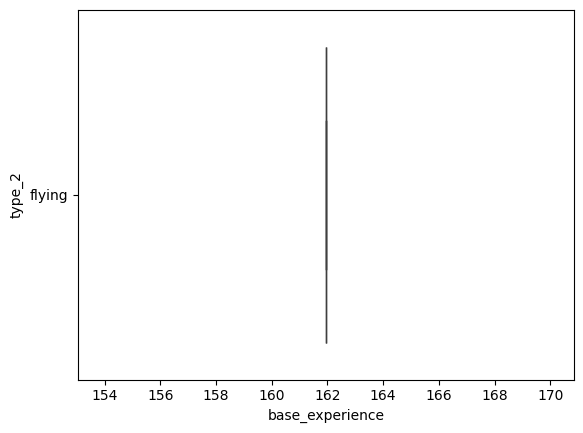

In [ ]:
sns.boxplot(x="base_experience", y="type_2", data=df)
plt.show()

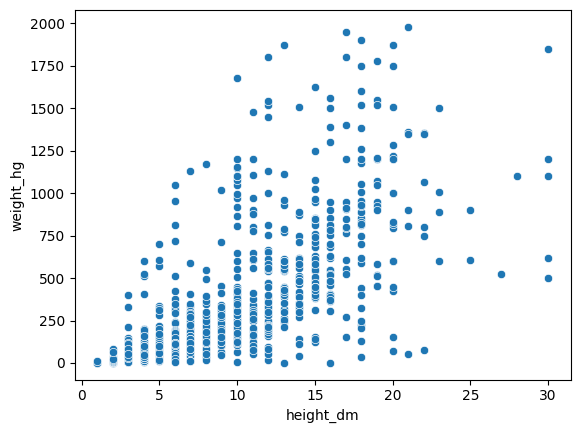

In [ ]:
sns.scatterplot(x="height_dm", y="weight_hg", data=df)
plt.show()

1. type_2

2. yes



Machine Learning Model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42 )

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(
      random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {

"KNN": KNeighborsClassifier(),
"Decision Tree": DecisionTreeClassifier(),
"Random Forest": RandomForestClassifier()
}

for name, model in models.items():

   model.fit(X_train_scaled, y_train)
   y_pred = model.predict(X_test)
   acc = accuracy_score(y_test, y_pred)
   print(f"{name} : {acc:.4f}")

KNN : 1.0000
Decision Tree : 1.0000
Random Forest : 1.0000


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [ ]:
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 1.0
Precision: 0.0
Recall : 0.0
F1 Score : 0.0

Confusion Matrix
[[179]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py

In [ ]:
from sklearn.model_selection import cross_val_score
for name, model in models.items():

  scores = cross_val_score(
  model,
  X,
  y,
  cv=5,
  scoring="accuracy"
)

print(f"{name}")
print("Scores:", scores)
print("Mean Accuracy:", scores.mean())
print()

Random Forest
Scores: [1. 1. 1. 1. 1.]
Mean Accuracy: 1.0



In [ ]:
best_score = 0
best_model = ""

for name, model in models.items():

   scores = cross_val_score(
   model,
   X,
   y,
   cv=5,
   scoring="accuracy"
)

mean_score = scores.mean()

if mean_score > best_score:
   best_score = mean_score
   best_model = name

print("Best Model:", best_model)
print("Best Score:", best_score)

Best Model: Random Forest
Best Score: 1.0


1. Random Forest beacause this classifier combine all models and predict the best model

2. type_2

3. base_experience